## Modelling

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

test = pd.read_csv("/Users/jiehni/titanic_survival_analysis/data/test.csv")
train = pd.read_csv("/Users/jiehni/titanic_survival_analysis/data/train.csv")

### Logistic Regression

In [3]:
# drop irrelevant variables
train = train.drop(["Name", "Ticket", "Cabin"], axis=1)
test = test.drop(["Name", "Ticket", "Cabin"], axis=1)

# one hot encoding
train["Sex"] = train["Sex"].map({'male':0, 'female':1})
test["Sex"]= test["Sex"].map({'male':0, 'female':1})
train["Embarked"] = train["Embarked"].map({'S':0, 'C':1, 'Q':2})
test["Embarked"] = test["Embarked"].map({'S':0, 'C':1, 'Q':2})

# fill missing values
train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())

train["Embarked"] = train["Embarked"].fillna(0)
test["Embarked"] = test["Embarked"].fillna(0)

test["Fare"] = test["Fare"].fillna(test["Fare"].median())

In [4]:
# define features and target of logistic regression
X = train.drop(["Survived", "PassengerId"], axis=1)
y = train["Survived"]

# perform train/test split
# note:
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8, random_state=0)

# logistic regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [5]:
# evaluate model on train dataset
lr_preds = lr_model.predict(X_val)
lr_accuracy = accuracy_score(y_val, lr_preds)
print("Accuracy:", lr_accuracy)

cm = confusion_matrix(y_val, lr_preds)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Dead", "Actual Survived"],
    columns=["Predicted Dead", "Predicted Survived"]
)
print(cm_df)

Accuracy: 0.8212290502793296
                 Predicted Dead  Predicted Survived
Actual Dead                  93                  17
Actual Survived              15                  54


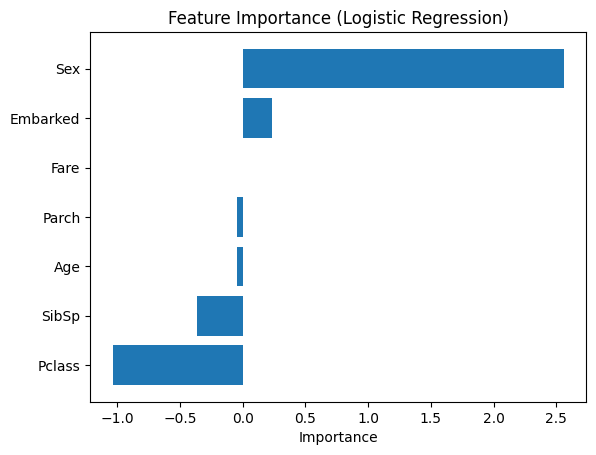

In [6]:
# feature importance
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})
feature_imp = coefficients.sort_values("Coefficient")

plt.barh(feature_imp["Feature"], feature_imp["Coefficient"])
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Importance")
plt.show()

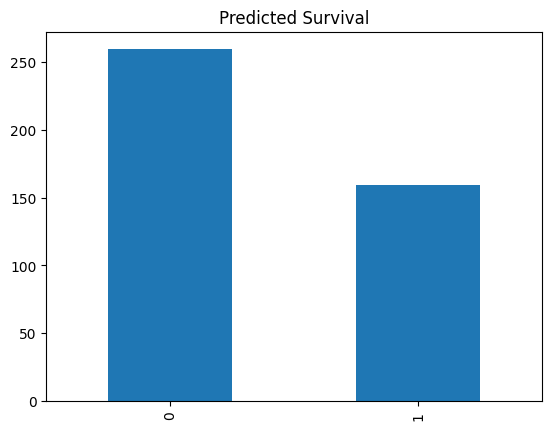

In [9]:
# predict on test dataset
X_test = test.drop("PassengerId", axis=1)
lr_test_preds = lr_model.predict(X_test)

lr_output = pd.DataFrame({"PassengerId": test.PassengerId, "Survived": lr_test_preds})
lr_output.to_csv("/Users/jiehni/titanic_survival_analysis/models/logistic_regression_model.csv", index=False)

# visualise results
import matplotlib.pyplot as plt

pd.Series(lr_test_preds).value_counts().plot(kind='bar')
plt.title("Predicted Survival")
plt.show()

### Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier

y1 = train["Survived"]
features = ["Pclass", "Sex", "SibSp", "Parch"]
X1 = pd.get_dummies(train[features]) # one hot encoding
X1_test = pd.get_dummies(test[features])

# random forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)
rf_accuracy = accuracy_score(y_val, rf_preds)
print("Accuracy:", rf_accuracy)

Accuracy: 0.8379888268156425


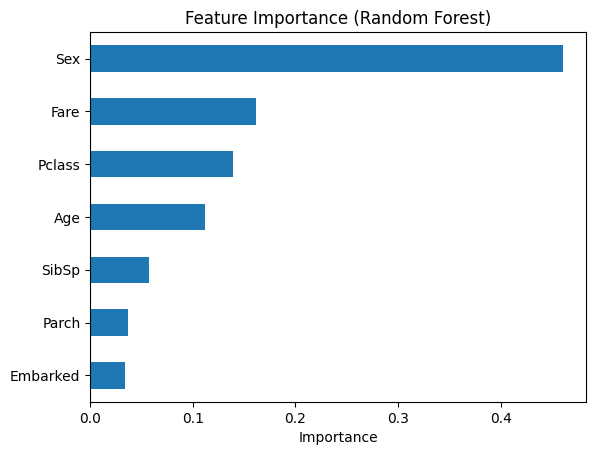

In [10]:
# feature importance
importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_imp = pd.Series(importances, index=feature_names)

feature_imp.sort_values().plot(kind="barh")

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [12]:
# predict test dataset
rf_model.fit(X1, y1)
rf_test_preds = rf_model.predict(X1_test)

rf_output = pd.DataFrame({"PassengerId": test.PassengerId, "Survived": rf_test_preds})
rf_output.to_csv("/Users/jiehni/titanic_survival_analysis/models/random_forest_model.csv", index=False)

### K Nearest Neighbours

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# knn model
knn_model = Pipeline([
    ("scaler", StandardScaler()),      
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_val)
knn_accuracy = accuracy_score(y_val, knn_preds)
print("Accuracy:", knn_accuracy)

Accuracy: 0.8268156424581006


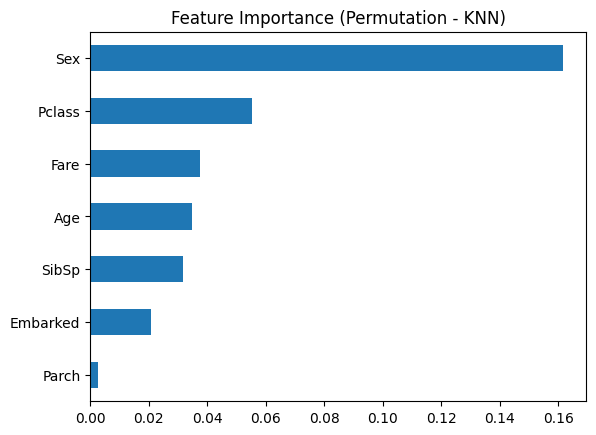

In [14]:
# permutation importance
from sklearn.inspection import permutation_importance

result = permutation_importance(
    knn_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=0
)

importance = pd.Series(result.importances_mean, index=X_val.columns)
importance.sort_values().plot(kind="barh")

plt.title("Feature Importance (Permutation - KNN)")
plt.show()

### Feature Importance Observations
- Sex is the most important feature in all models, showing gender strongly influenced survival.
- Pclass is the second most important, indicating higher-class passengers had better survival chances.
- Fare and Age have moderate influence on predictions.
- SibSp, Parch, and Embarked contribute less, suggesting weaker impact on survival.

In [15]:
# predict on test dataset
knn_test_preds = knn_model.predict(X_test)

knn_output = pd.DataFrame({"PassengerId": test.PassengerId, "Survived": knn_test_preds})
knn_output.to_csv("/Users/jiehni/titanic_survival_analysis/models/knn_model.csv", index=False)

### Model Comparison

In [18]:
accuracy = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN"],
    "Accuracy": [lr_accuracy, rf_accuracy, knn_accuracy]
})

print(accuracy)

                 Model  Accuracy
0  Logistic Regression  0.821229
1        Random Forest  0.837989
2                  KNN  0.826816


- Random forest model achieved the highest accuracy (0.8380), showing strong performance from tree-based ensemble methods.
- KNN (0.8268) and logistic regression model (0.8212) performed slightly worse but still produced similar results.

Overall, ensemble models outperformed simpler models which suggests the existence of nonlinear relationships between the feature variables and the target variable (survival).